# Long-Document Dataset Sequence-Length Analysis

Visualizes sequence-length samples for training dataset candidates. Expanded **2026-06-18** with datasets from SmolLM3, OLMo2, Ouro, and MrCogito baselines.

- **Catalog (metadata + model mixes):** `playground/training_dataset_catalog.ipynb` + `analysis/training_dataset_catalog.json`
- **Candidates config:** `analysis/long_dataset_candidates.json`
- **Sampler script:** `analysis/dataset_seqlen_distribution.py`

Goal: identify datasets that can force a sliding-window decoder to use concepts as cross-window memory.


In [12]:
from __future__ import annotations

import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Resolve repo root from playground/<this notebook> when run in Jupyter.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "playground":
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    # This also works when Jupyter is launched from the repo root.
    REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "pyproject.toml").exists() else NOTEBOOK_DIR.parent

SUMMARY_PATH = REPO_ROOT / "Cache" / "Evaluation_reports" / "seqlen_model_mix_100" / "seqlen_dist_summary.json"
CATALOG_PATH = REPO_ROOT / "analysis" / "training_dataset_catalog.json"
CANDIDATES_PATH = REPO_ROOT / "analysis" / "long_dataset_candidates.json"
SCRIPT_PATH = REPO_ROOT / "analysis" / "dataset_seqlen_distribution.py"

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print(f"Repo root: {REPO_ROOT}")
print(f"Summary path exists: {SUMMARY_PATH.exists()}")
print(f"Candidate file exists: {CANDIDATES_PATH.exists()}")

Repo root: /Users/ksirg/devel/MrCogito
Summary path exists: True
Candidate file exists: True


In [13]:
EMBEDDED_RESULTS = [
    {
        "name": "fineweb_edu_baseline",
        "dataset": "HuggingFaceFW/fineweb-edu",
        "subset": "sample-10BT",
        "split": "train",
        "total_docs": 100,
        "length_source": "token_count column",
        "stats": {
            "min": 99,
            "mean": 797.9,
            "p50": 503,
            "p75": 1097,
            "p90": 2152,
            "p95": 2482,
            "p99": 3683,
            "max": 3683
        },
        "bins_pct": {
            "<=256": 25.0,
            "<=512": 26.0,
            "<=1024": 21.0,
            "<=2048": 18.0,
            "<=4096": 10.0
        },
        "longer_than_pct": {
            "512": 49.0,
            "1024": 28.0,
            "2048": 10.0,
            "4096": 0.0,
            "8192": 0.0,
            "16384": 0.0,
            "32768": 0.0
        }
    },
    {
        "name": "finepdfs_100BT_pdf_pretrain",
        "dataset": "HuggingFaceFW/finepdfs_100BT",
        "subset": "default",
        "split": "train",
        "total_docs": 100,
        "length_source": "token_count column",
        "stats": {
            "min": 65,
            "mean": 3768.9,
            "p50": 1517,
            "p75": 3146,
            "p90": 10008,
            "p95": 15485,
            "p99": 50569,
            "max": 50569
        },
        "bins_pct": {
            "<=256": 9.0,
            "<=512": 12.0,
            "<=1024": 15.0,
            "<=2048": 28.0,
            "<=4096": 15.0,
            "<=8192": 10.0,
            "<=16384": 7.0,
            "<=32768": 2.0,
            ">32768": 2.0
        },
        "longer_than_pct": {
            "512": 79.0,
            "1024": 64.0,
            "2048": 36.0,
            "4096": 21.0,
            "8192": 11.0,
            "16384": 4.0,
            "32768": 2.0
        }
    },
    {
        "name": "dclm_baseline",
        "dataset": "mlfoundations/dclm-baseline-1.0",
        "subset": "default",
        "split": "train",
        "total_docs": 100,
        "length_source": "tokenizer:HuggingFaceTB/SmolLM2-135M",
        "stats": {
            "min": 80,
            "mean": 1040.7,
            "p50": 691,
            "p75": 1311,
            "p90": 2124,
            "p95": 4184,
            "p99": 5346,
            "max": 5346
        },
        "bins_pct": {
            "<=256": 17.0,
            "<=512": 19.0,
            "<=1024": 29.0,
            "<=2048": 25.0,
            "<=4096": 5.0,
            "<=8192": 5.0
        },
        "longer_than_pct": {
            "512": 64.0,
            "1024": 35.0,
            "2048": 10.0,
            "4096": 5.0,
            "8192": 0.0,
            "16384": 0.0,
            "32768": 0.0
        }
    },
    {
        "name": "finemath_3plus",
        "dataset": "HuggingFaceTB/finemath",
        "subset": "finemath-3plus",
        "split": "train",
        "total_docs": 100,
        "length_source": "token_count column",
        "stats": {
            "min": 40,
            "mean": 1811.9,
            "p50": 725,
            "p75": 1416,
            "p90": 2300,
            "p95": 2900,
            "p99": 65215,
            "max": 65215
        },
        "bins_pct": {
            "<=256": 8.0,
            "<=512": 22.0,
            "<=1024": 36.0,
            "<=2048": 21.0,
            "<=4096": 11.0,
            "<=32768": 1.0,
            ">32768": 1.0
        },
        "longer_than_pct": {
            "512": 70.0,
            "1024": 34.0,
            "2048": 13.0,
            "4096": 2.0,
            "8192": 2.0,
            "16384": 2.0,
            "32768": 1.0
        }
    },
    {
        "name": "finemath_4plus",
        "dataset": "HuggingFaceTB/finemath",
        "subset": "finemath-4plus",
        "split": "train",
        "total_docs": 100,
        "length_source": "token_count column",
        "stats": {
            "min": 95,
            "mean": 1191.4,
            "p50": 845,
            "p75": 1363,
            "p90": 2338,
            "p95": 3382,
            "p99": 9383,
            "max": 9383
        },
        "bins_pct": {
            "<=256": 11.0,
            "<=512": 12.0,
            "<=1024": 40.0,
            "<=2048": 25.0,
            "<=4096": 9.0,
            "<=8192": 2.0,
            "<=16384": 1.0
        },
        "longer_than_pct": {
            "512": 77.0,
            "1024": 37.0,
            "2048": 12.0,
            "4096": 3.0,
            "8192": 1.0,
            "16384": 0.0,
            "32768": 0.0
        }
    },
    {
        "name": "dolmino_mix",
        "dataset": "allenai/dolmino-mix-1124",
        "subset": "default",
        "split": "train",
        "total_docs": 100,
        "length_source": "tokenizer:HuggingFaceTB/SmolLM2-135M",
        "stats": {
            "min": 95,
            "mean": 1227.4,
            "p50": 778,
            "p75": 1450,
            "p90": 2715,
            "p95": 4292,
            "p99": 6372,
            "max": 6372
        },
        "bins_pct": {
            "<=256": 15.0,
            "<=512": 18.0,
            "<=1024": 28.0,
            "<=2048": 23.0,
            "<=4096": 11.0,
            "<=8192": 5.0
        },
        "longer_than_pct": {
            "512": 67.0,
            "1024": 39.0,
            "2048": 16.0,
            "4096": 5.0,
            "8192": 0.0,
            "16384": 0.0,
            "32768": 0.0
        }
    },
    {
        "name": "olmo_mix",
        "dataset": "allenai/olmo-mix-1124",
        "subset": "default",
        "split": "train",
        "total_docs": 100,
        "length_source": "tokenizer:HuggingFaceTB/SmolLM2-135M",
        "stats": {
            "min": 1322,
            "mean": 20228.4,
            "p50": 14871,
            "p75": 24249,
            "p90": 37010,
            "p95": 53975,
            "p99": 138439,
            "max": 138439
        },
        "bins_pct": {
            "<=2048": 1.0,
            "<=4096": 4.0,
            "<=8192": 14.0,
            "<=16384": 38.0,
            "<=32768": 33.0,
            ">32768": 10.0
        },
        "longer_than_pct": {
            "512": 100.0,
            "1024": 100.0,
            "2048": 99.0,
            "4096": 95.0,
            "8192": 81.0,
            "16384": 43.0,
            "32768": 10.0
        }
    },
    {
        "name": "cosmopedia_v2",
        "dataset": "HuggingFaceTB/cosmopedia-v2",
        "subset": "cosmopedia-v2",
        "split": "train",
        "total_docs": 100,
        "length_source": "token_length column",
        "stats": {
            "min": 28,
            "mean": 798.9,
            "p50": 732,
            "p75": 936,
            "p90": 1272,
            "p95": 1371,
            "p99": 1682,
            "max": 1682
        },
        "bins_pct": {
            "<=256": 1.0,
            "<=512": 5.0,
            "<=1024": 74.0,
            "<=2048": 20.0
        },
        "longer_than_pct": {
            "512": 94.0,
            "1024": 20.0,
            "2048": 0.0,
            "4096": 0.0,
            "8192": 0.0,
            "16384": 0.0,
            "32768": 0.0
        }
    },
    {
        "name": "stack_edu_python",
        "dataset": "meryyllebr543/stack-edu-huggingface",
        "subset": "python",
        "split": "train",
        "total_docs": 100,
        "length_source": "tokenizer:HuggingFaceTB/SmolLM2-135M",
        "stats": {
            "min": 33,
            "mean": 902.6,
            "p50": 422,
            "p75": 945,
            "p90": 2064,
            "p95": 4956,
            "p99": 6239,
            "max": 6239
        },
        "bins_pct": {
            "<=256": 33.0,
            "<=512": 21.0,
            "<=1024": 25.0,
            "<=2048": 11.0,
            "<=4096": 5.0,
            "<=8192": 5.0
        },
        "longer_than_pct": {
            "512": 46.0,
            "1024": 21.0,
            "2048": 10.0,
            "4096": 5.0,
            "8192": 0.0,
            "16384": 0.0,
            "32768": 0.0
        }
    },
    {
        "name": "opc_annealing_synthetic_qa",
        "dataset": "OpenCoder-LLM/opc-annealing-corpus",
        "subset": "synthetic_qa",
        "split": "train",
        "total_docs": 100,
        "length_source": "tokenizer:HuggingFaceTB/SmolLM2-135M",
        "stats": {
            "min": 80,
            "mean": 538.7,
            "p50": 409,
            "p75": 691,
            "p90": 1182,
            "p95": 1453,
            "p99": 2515,
            "max": 2515
        },
        "bins_pct": {
            "<=256": 31.0,
            "<=512": 30.0,
            "<=1024": 25.0,
            "<=2048": 12.0,
            "<=4096": 2.0
        },
        "longer_than_pct": {
            "512": 39.0,
            "1024": 14.0,
            "2048": 2.0,
            "4096": 0.0,
            "8192": 0.0,
            "16384": 0.0,
            "32768": 0.0
        }
    },
    {
        "name": "longblocks_doc_qa_reasoning",
        "dataset": "utter-project/LongBlocks",
        "subset": "default",
        "split": "train",
        "total_docs": 100,
        "length_source": "tokenizer:HuggingFaceTB/SmolLM2-135M",
        "stats": {
            "min": 595,
            "mean": 29492.4,
            "p50": 4816,
            "p75": 47542,
            "p90": 85317,
            "p95": 90721,
            "p99": 291622,
            "max": 291622
        },
        "bins_pct": {
            "<=1024": 3.0,
            "<=2048": 13.0,
            "<=4096": 29.0,
            "<=8192": 12.0,
            "<=32768": 10.0,
            ">32768": 33.0
        },
        "longer_than_pct": {
            "512": 100.0,
            "1024": 97.0,
            "2048": 84.0,
            "4096": 55.0,
            "8192": 43.0,
            "16384": 43.0,
            "32768": 33.0
        }
    },
    {
        "name": "openmathreasoning_cot",
        "dataset": "nvidia/OpenMathReasoning",
        "subset": "default",
        "split": "cot",
        "total_docs": 100,
        "length_source": "tokenizer:HuggingFaceTB/SmolLM2-135M",
        "stats": {
            "min": 904,
            "mean": 7590.1,
            "p50": 6835,
            "p75": 12216,
            "p90": 15473,
            "p95": 16627,
            "p99": 18858,
            "max": 18858
        },
        "bins_pct": {
            "<=1024": 3.0,
            "<=2048": 8.0,
            "<=4096": 18.0,
            "<=8192": 32.0,
            "<=16384": 34.0,
            "<=32768": 5.0
        },
        "longer_than_pct": {
            "512": 100.0,
            "1024": 97.0,
            "2048": 89.0,
            "4096": 71.0,
            "8192": 39.0,
            "16384": 5.0,
            "32768": 0.0
        }
    },
    {
        "name": "big_reasoning_traces",
        "dataset": "allenai/big-reasoning-traces",
        "subset": "DeepSeek",
        "split": "train",
        "total_docs": 100,
        "length_source": "num_tokens column",
        "stats": {
            "min": 60,
            "mean": 3506.7,
            "p50": 1417,
            "p75": 3770,
            "p90": 8673,
            "p95": 17444,
            "p99": 23197,
            "max": 23197
        },
        "bins_pct": {
            "<=256": 2.0,
            "<=512": 2.0,
            "<=1024": 22.0,
            "<=2048": 41.0,
            "<=4096": 11.0,
            "<=8192": 12.0,
            "<=16384": 4.0,
            "<=32768": 6.0
        },
        "longer_than_pct": {
            "512": 96.0,
            "1024": 74.0,
            "2048": 33.0,
            "4096": 22.0,
            "8192": 10.0,
            "16384": 6.0,
            "32768": 0.0
        }
    },
    {
        "name": "openthoughts3_math_code_science",
        "dataset": "open-thoughts/OpenThoughts3-1.2M",
        "subset": "default",
        "split": "train",
        "total_docs": 100,
        "length_source": "tokenizer:HuggingFaceTB/SmolLM2-135M",
        "stats": {
            "min": 3175,
            "mean": 18125.8,
            "p50": 19619,
            "p75": 20142,
            "p90": 20804,
            "p95": 21579,
            "p99": 23544,
            "max": 23544
        },
        "bins_pct": {
            "<=4096": 1.0,
            "<=8192": 2.0,
            "<=16384": 17.0,
            "<=32768": 80.0
        },
        "longer_than_pct": {
            "512": 100.0,
            "1024": 100.0,
            "2048": 100.0,
            "4096": 99.0,
            "8192": 97.0,
            "16384": 80.0,
            "32768": 0.0
        }
    }
]

CANDIDATE_NOTES = [
    {
        "dataset": "HuggingFaceFW/fineweb-edu (sample-10BT)",
        "scale": "~1.3T full; 10B sample on HF",
        "type": "pretrain",
        "used_by": "smollm2, smollm3, qwen25, qwen3, mrcogito",
        "why": "median ~631 tokens (HF stats); short-doc heavy; broad web knowledge, English-primary"
    },
    {
        "dataset": "mlfoundations/dclm-baseline-1.0 (default)",
        "scale": "~2.6T tokens",
        "type": "pretrain",
        "used_by": "smollm3, olmo2, ettin",
        "why": "web-crawl; similar short-doc tail to FineWeb; high-quality open web crawl"
    },
    {
        "dataset": "HuggingFaceFW/fineweb-2 (per-language configs (e.g. deu_Latn))",
        "scale": "multilingual web; 100BT+ samples per language",
        "type": "pretrain",
        "used_by": "smollm3",
        "why": "web-crawl; language-specific; 1000+ languages; SmolLM3 uses ~12% multilingual"
    },
    {
        "dataset": "HuggingFaceFW/finepdfs_100BT (default)",
        "scale": "100B sample; ~3T parent",
        "type": "pretrain",
        "used_by": "qwen3, mrcogito_e05",
        "why": "p50 ~1.5k; long tail to 50k+; varied PDF-derived docs; better long tail than FineWeb-Edu"
    },
    {
        "dataset": "HuggingFaceTB/finemath (finemath-3plus / finemath-4plus)",
        "scale": "tens of B tokens per subset",
        "type": "pretrain",
        "used_by": "smollm2, smollm3, qwen25, qwen3",
        "why": "math pages; moderate length; math-only but high quality"
    },
    {
        "dataset": "HuggingFaceTB/stack-edu (Python (and 14 other langs))",
        "scale": "125B tokens total",
        "type": "code pretrain",
        "used_by": "smollm2, smollm3, qwen3",
        "why": "file-level; variable, often 500-8k; 15 languages; educational filter"
    },
    {
        "dataset": "LLM360/MegaMath (default (code-heavy on HF))",
        "scale": "371B tokens (paper); web/code/synthetic variants",
        "type": "pretrain",
        "used_by": "ouro, smollm3, qwen3",
        "why": "web avg ~2.3k tokens; synthetic shorter; math-focused; used by Ouro and SmolLM3 Stage 2+"
    },
    {
        "dataset": "allenai/dolmino-mix-1124 (default)",
        "scale": "1.124T tokens",
        "type": "pretrain mix",
        "used_by": "olmo2",
        "why": "mixed; web-dominated short docs; very high \u2014 OLMo 2 canonical mix"
    },
    {
        "dataset": "allenai/olmo-mix-1124 (default)",
        "scale": "part of OLMo 2 training",
        "type": "pretrain mix",
        "used_by": "olmo2",
        "why": "mixed web; OLMo 2 release mix"
    },
    {
        "dataset": "allenai/dolma (v1_7)",
        "scale": "2.3T tokens (v1.7)",
        "type": "pretrain",
        "used_by": "olmo2",
        "why": "mixed; foundational open corpus"
    },
    {
        "dataset": "allenai/peS2o (default)",
        "scale": "scientific papers (S2ORC-derived)",
        "type": "pretrain",
        "used_by": "olmo2, ettin, dolma",
        "why": "5k-30k tokens typical for full papers; scientific; coherent long docs"
    },
    {
        "dataset": "nvidia/Nemotron-CC-v2 (various (Sample public))",
        "scale": "6.3T tokens",
        "type": "pretrain",
        "used_by": "ouro",
        "why": "web; Ouro uses 16k seq in anneal \u2014 implies moderate+; high-quality web; Ouro primary corpus"
    },
    {
        "dataset": "mlfoundations/MAP-CC",
        "scale": "~800B tokens (Ouro Stage 1)",
        "type": "pretrain",
        "used_by": "ouro",
        "why": "web; multilingual web"
    },
    {
        "dataset": "HuggingFaceFW/ultrafineweb-zh",
        "scale": "~120B tokens (Ouro Stage 1)",
        "type": "pretrain",
        "used_by": "ouro",
        "why": "web; Chinese only; Ouro dropped after Stage 1"
    },
    {
        "dataset": "OpenCoder-LLM/opencoder-pretrain",
        "scale": "~450B tokens (Ouro Stage 1)",
        "type": "code pretrain",
        "used_by": "ouro",
        "why": "file/repo level; code"
    },
    {
        "dataset": "OpenCoder-LLM/opc-annealing-corpus (synthetic_qa / synthetic_code_snippet)",
        "scale": "~7B tokens",
        "type": "annealing",
        "used_by": "ouro",
        "why": "code snippets; moderate; code-focused synthetic"
    },
    {
        "dataset": "princeton-nlp/prolong-data-64K (default)",
        "scale": "20B tokens (Ouro LongCT)",
        "type": "long-context",
        "used_by": "ouro",
        "why": "pre-packed 65,536 tokens; long coherent docs"
    },
    {
        "dataset": "HuggingFaceTB/cosmopedia-v2 (cosmopedia-v2)",
        "scale": "39M synthetic textbooks",
        "type": "synthetic pretrain",
        "used_by": "smollm",
        "why": "token_length column available; synthetic educational; SmolLM family"
    },
    {
        "dataset": "utter-project/LongBlocks (default)",
        "scale": "57.6k rows",
        "type": "SFT / long-context",
        "used_by": "mrcogito_e05",
        "why": "p50 ~5k; 33% >32k in 100-row sample; best varied ultra-long SFT candidate"
    },
    {
        "dataset": "nvidia/OpenMathReasoning (default)",
        "scale": "3.2M CoT + 1.7M TIR",
        "type": "reasoning",
        "used_by": "ouro, smollm3, mrcogito",
        "why": "p50 ~7k tokens; math reasoning traces"
    },
    {
        "dataset": "open-thoughts/OpenThoughts3-1.2M (default)",
        "scale": "1.2M rows",
        "type": "reasoning SFT",
        "used_by": "ouro, smollm3, mrcogito",
        "why": "p50 ~20k; consistently long; reasoning traces; not broad world knowledge"
    },
    {
        "dataset": "allenai/big-reasoning-traces (DeepSeek)",
        "scale": "~2.5B tokens",
        "type": "reasoning mid-train",
        "used_by": "olmo2, ouro",
        "why": "p50 ~1.4k; weaker ultra-long tail; OLMo 2 reasoning mix component"
    },
    {
        "dataset": "jhu-clsp/ettin-pretraining-data (default)",
        "scale": "1.7T tokens",
        "type": "pretrain mix",
        "used_by": "ettin",
        "why": "mixed; excellent blend; MDS/TAR format"
    }
]

if SUMMARY_PATH.exists():
    results = json.loads(SUMMARY_PATH.read_text())
    source = f"Loaded from {SUMMARY_PATH.relative_to(REPO_ROOT)}"
else:
    results = EMBEDDED_RESULTS
    source = "Using embedded 2026-06-18 fallback sample"

print(source)
print(f"Loaded {len(results)} sampled candidates")


Loaded from Cache/Evaluation_reports/seqlen_model_mix_100/seqlen_dist_summary.json
Loaded 14 sampled candidates


In [14]:
def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = []
    for row in rows:
        body.append("| " + " | ".join(str(row.get(col, "")).replace("\n", "<br>") for col in columns) + " |")
    return "\n".join([header, sep, *body])

# Show scouting notes beyond just the five measured datasets.
display(Markdown("## Candidate Scout Notes\n" + markdown_table(CANDIDATE_NOTES, ["dataset", "scale", "type", "used_by", "why"])))

## Candidate Scout Notes
| dataset | scale | type | used_by | why |
| --- | --- | --- | --- | --- |
| HuggingFaceFW/fineweb-edu (sample-10BT) | ~1.3T full; 10B sample on HF | pretrain | smollm2, smollm3, qwen25, qwen3, mrcogito | median ~631 tokens (HF stats); short-doc heavy; broad web knowledge, English-primary |
| mlfoundations/dclm-baseline-1.0 (default) | ~2.6T tokens | pretrain | smollm3, olmo2, ettin | web-crawl; similar short-doc tail to FineWeb; high-quality open web crawl |
| HuggingFaceFW/fineweb-2 (per-language configs (e.g. deu_Latn)) | multilingual web; 100BT+ samples per language | pretrain | smollm3 | web-crawl; language-specific; 1000+ languages; SmolLM3 uses ~12% multilingual |
| HuggingFaceFW/finepdfs_100BT (default) | 100B sample; ~3T parent | pretrain | qwen3, mrcogito_e05 | p50 ~1.5k; long tail to 50k+; varied PDF-derived docs; better long tail than FineWeb-Edu |
| HuggingFaceTB/finemath (finemath-3plus / finemath-4plus) | tens of B tokens per subset | pretrain | smollm2, smollm3, qwen25, qwen3 | math pages; moderate length; math-only but high quality |
| HuggingFaceTB/stack-edu (Python (and 14 other langs)) | 125B tokens total | code pretrain | smollm2, smollm3, qwen3 | file-level; variable, often 500-8k; 15 languages; educational filter |
| LLM360/MegaMath (default (code-heavy on HF)) | 371B tokens (paper); web/code/synthetic variants | pretrain | ouro, smollm3, qwen3 | web avg ~2.3k tokens; synthetic shorter; math-focused; used by Ouro and SmolLM3 Stage 2+ |
| allenai/dolmino-mix-1124 (default) | 1.124T tokens | pretrain mix | olmo2 | mixed; web-dominated short docs; very high — OLMo 2 canonical mix |
| allenai/olmo-mix-1124 (default) | part of OLMo 2 training | pretrain mix | olmo2 | mixed web; OLMo 2 release mix |
| allenai/dolma (v1_7) | 2.3T tokens (v1.7) | pretrain | olmo2 | mixed; foundational open corpus |
| allenai/peS2o (default) | scientific papers (S2ORC-derived) | pretrain | olmo2, ettin, dolma | 5k-30k tokens typical for full papers; scientific; coherent long docs |
| nvidia/Nemotron-CC-v2 (various (Sample public)) | 6.3T tokens | pretrain | ouro | web; Ouro uses 16k seq in anneal — implies moderate+; high-quality web; Ouro primary corpus |
| mlfoundations/MAP-CC | ~800B tokens (Ouro Stage 1) | pretrain | ouro | web; multilingual web |
| HuggingFaceFW/ultrafineweb-zh | ~120B tokens (Ouro Stage 1) | pretrain | ouro | web; Chinese only; Ouro dropped after Stage 1 |
| OpenCoder-LLM/opencoder-pretrain | ~450B tokens (Ouro Stage 1) | code pretrain | ouro | file/repo level; code |
| OpenCoder-LLM/opc-annealing-corpus (synthetic_qa / synthetic_code_snippet) | ~7B tokens | annealing | ouro | code snippets; moderate; code-focused synthetic |
| princeton-nlp/prolong-data-64K (default) | 20B tokens (Ouro LongCT) | long-context | ouro | pre-packed 65,536 tokens; long coherent docs |
| HuggingFaceTB/cosmopedia-v2 (cosmopedia-v2) | 39M synthetic textbooks | synthetic pretrain | smollm | token_length column available; synthetic educational; SmolLM family |
| utter-project/LongBlocks (default) | 57.6k rows | SFT / long-context | mrcogito_e05 | p50 ~5k; 33% >32k in 100-row sample; best varied ultra-long SFT candidate |
| nvidia/OpenMathReasoning (default) | 3.2M CoT + 1.7M TIR | reasoning | ouro, smollm3, mrcogito | p50 ~7k tokens; math reasoning traces |
| open-thoughts/OpenThoughts3-1.2M (default) | 1.2M rows | reasoning SFT | ouro, smollm3, mrcogito | p50 ~20k; consistently long; reasoning traces; not broad world knowledge |
| allenai/big-reasoning-traces (DeepSeek) | ~2.5B tokens | reasoning mid-train | olmo2, ouro | p50 ~1.4k; weaker ultra-long tail; OLMo 2 reasoning mix component |
| jhu-clsp/ettin-pretraining-data (default) | 1.7T tokens | pretrain mix | ettin | mixed; excellent blend; MDS/TAR format |

In [15]:
def short_name(name: str) -> str:
    return {
        "fineweb_edu_baseline": "FineWeb-Edu",
        "finepdfs_100BT_pdf_pretrain": "FinePDFs-100BT",
        "dclm_baseline": "DCLM",
        "finemath_3plus": "FineMath-3+",
        "finemath_4plus": "FineMath-4+",
        "dolmino_mix": "Dolmino",
        "olmo_mix": "OLMo-mix",
        "cosmopedia_v2": "Cosmopedia-v2",
        "stack_edu_python": "Stack-Edu-Py",
        "opc_annealing_synthetic_qa": "OpenCoder-QA",
        "longblocks_doc_qa_reasoning": "LongBlocks",
        "openmathreasoning_cot": "OpenMathReasoning",
        "big_reasoning_traces": "BigReasoningTraces",
        "openthoughts3_math_code_science": "OpenThoughts3",
    }.get(name, name)


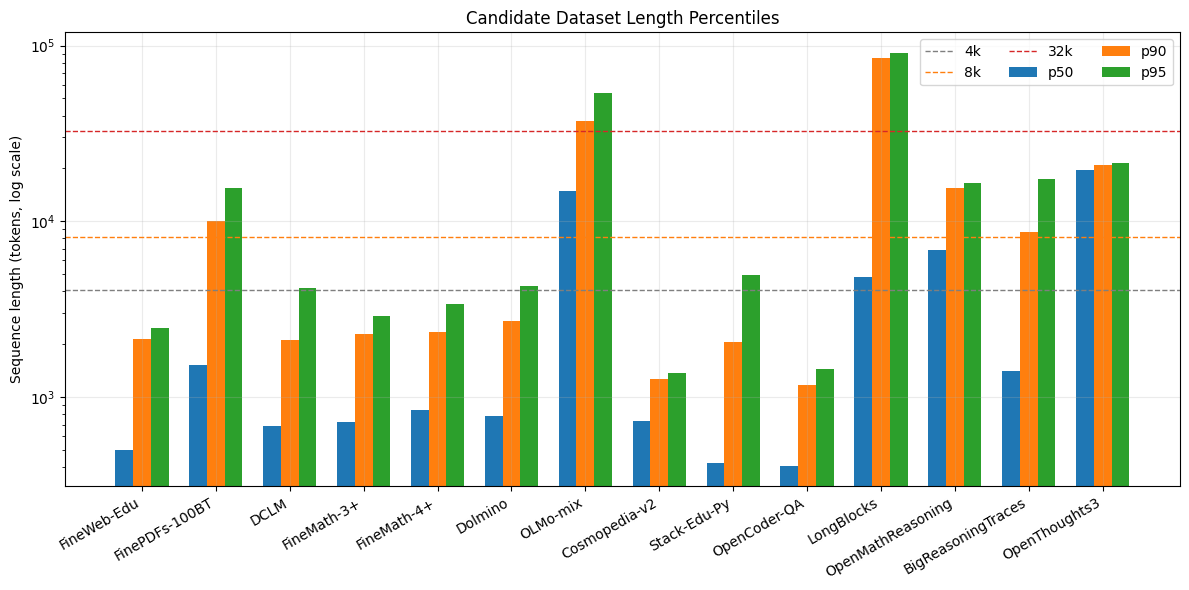

In [16]:
names = [short_name(r["name"]) for r in results]
percentiles = ["p50", "p90", "p95"]
width = 0.24
x = list(range(len(names)))

fig, ax = plt.subplots(figsize=(12, 6))
for i, pct in enumerate(percentiles):
    values = [r["stats"][pct] for r in results]
    offsets = [v + (i - 1) * width for v in x]
    ax.bar(offsets, values, width=width, label=pct)

ax.axhline(4096, color="tab:gray", linestyle="--", linewidth=1, label="4k")
ax.axhline(8192, color="tab:orange", linestyle="--", linewidth=1, label="8k")
ax.axhline(32768, color="tab:red", linestyle="--", linewidth=1, label="32k")
ax.set_yscale("log")
ax.set_ylabel("Sequence length (tokens, log scale)")
ax.set_title("Candidate Dataset Length Percentiles")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

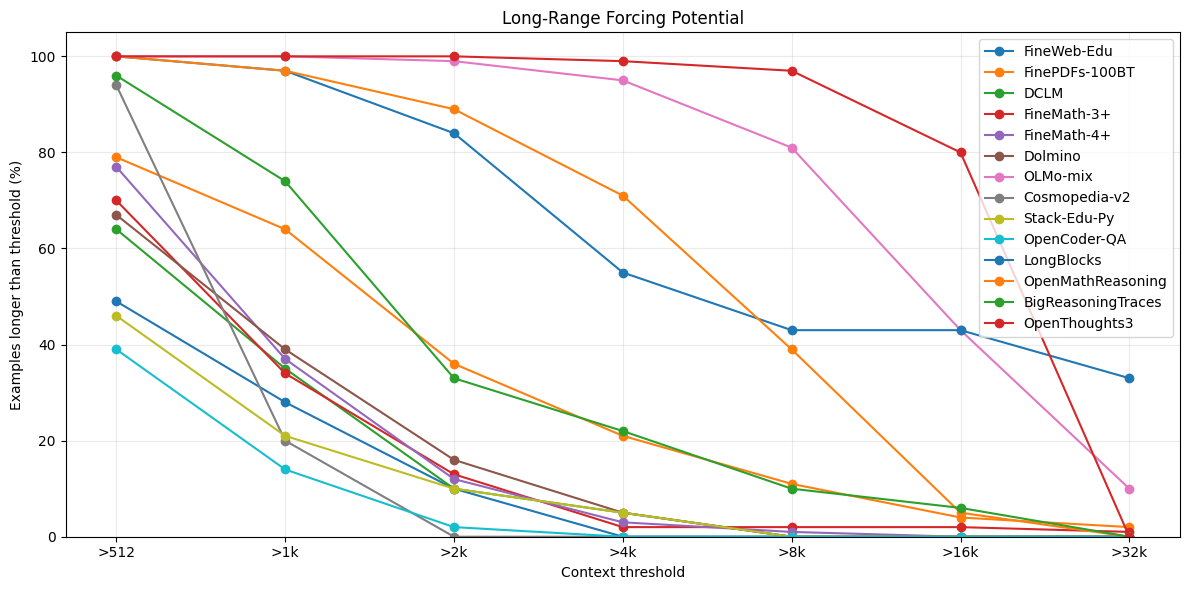

In [17]:
thresholds = [512, 1024, 2048, 4096, 8192, 16384, 32768]

fig, ax = plt.subplots(figsize=(12, 6))
for result in results:
    y = [result["longer_than_pct"].get(str(t), 0.0) for t in thresholds]
    ax.plot(thresholds, y, marker="o", label=short_name(result["name"]))

ax.set_xscale("log", base=2)
ax.set_xticks(thresholds)
ax.set_xticklabels([f">{t//1024}k" if t >= 1024 else f">{t}" for t in thresholds])
ax.set_ylim(0, 105)
ax.set_ylabel("Examples longer than threshold (%)")
ax.set_xlabel("Context threshold")
ax.set_title("Long-Range Forcing Potential")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

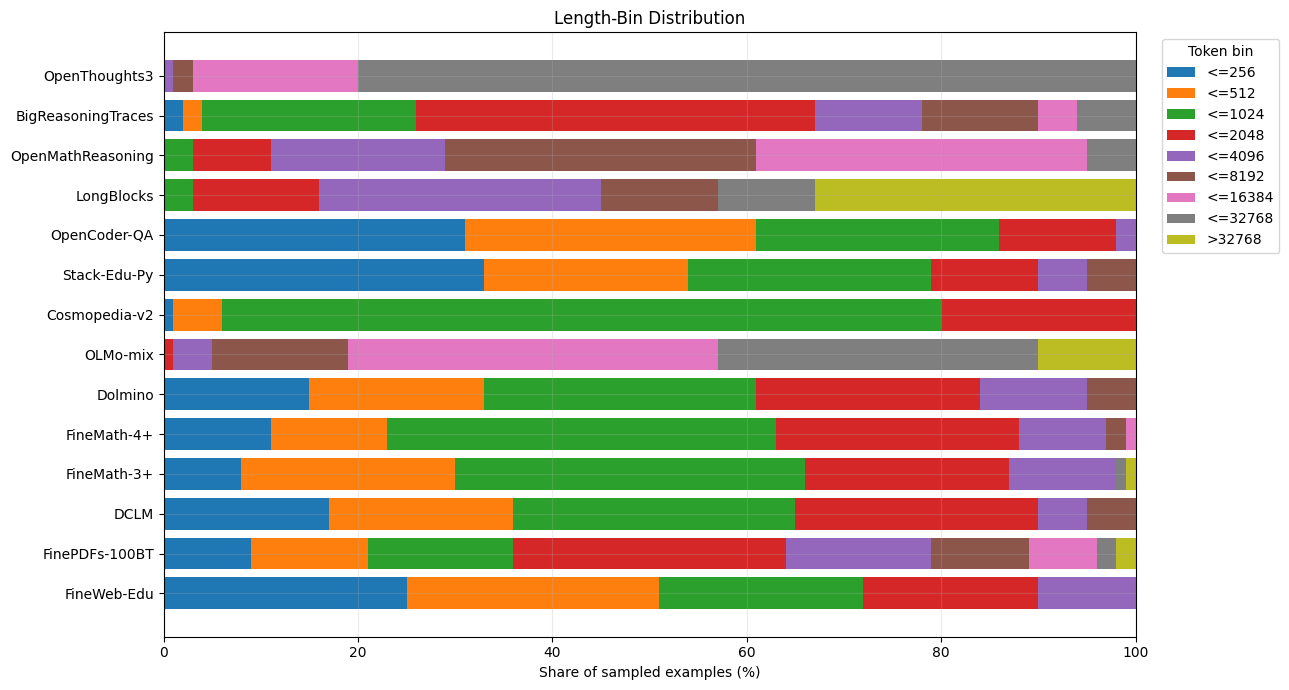

In [18]:
BIN_ORDER = ["<=256", "<=512", "<=1024", "<=2048", "<=4096", "<=8192", "<=16384", "<=32768", ">32768"]

fig, ax = plt.subplots(figsize=(13, 7))
y_positions = list(range(len(results)))
left = [0.0] * len(results)

for bin_label in BIN_ORDER:
    values = [r.get("bins_pct", {}).get(bin_label, 0.0) for r in results]
    if not any(values):
        continue
    ax.barh(y_positions, values, left=left, label=bin_label)
    left = [l + v for l, v in zip(left, values)]

ax.set_yticks(y_positions)
ax.set_yticklabels([short_name(r["name"]) for r in results])
ax.set_xlabel("Share of sampled examples (%)")
ax.set_title("Length-Bin Distribution")
ax.legend(title="Token bin", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
# Optional: rerun the sampler locally.
# This uses the reusable script and candidate file created during the analysis.
# It is CPU-only. Larger max_docs values improve percentile stability but download/stream more data.

RUN_FRESH_SAMPLE = False
MAX_DOCS = 500  # try 100 first; 1_000-10_000 is better for stable tails
OUT_DIR = REPO_ROOT / "Cache" / "Evaluation_reports" / f"seqlen_long_candidates_{MAX_DOCS}"
TOKENIZER = "HuggingFaceTB/SmolLM2-135M"

cmd = [
    "uv", "run", "python", str(SCRIPT_PATH),
    "--candidates", str(CANDIDATES_PATH),
    "--tokenizer", TOKENIZER,
    "--max_docs", str(MAX_DOCS),
    "--out_dir", str(OUT_DIR),
]

print(" ".join(cmd))

if RUN_FRESH_SAMPLE:
    subprocess.run(cmd, cwd=REPO_ROOT, check=True)
    fresh_summary = OUT_DIR / "seqlen_dist_summary.json"
    print(f"Fresh summary written to: {fresh_summary}")
else:
    print("Set RUN_FRESH_SAMPLE = True to execute this command.")

uv run python /Users/ksirg/devel/MrCogito/analysis/dataset_seqlen_distribution.py --candidates /Users/ksirg/devel/MrCogito/analysis/long_dataset_candidates.json --tokenizer HuggingFaceTB/SmolLM2-135M --max_docs 500 --out_dir /Users/ksirg/devel/MrCogito/Cache/Evaluation_reports/seqlen_long_candidates_500
Set RUN_FRESH_SAMPLE = True to execute this command.


## Interpretation (2026-06-18, 100-row sample)

For a sliding-window decoder with last-K local context, useful training data needs coherent examples that extend well beyond K.

### By training-program family

- **MrCogito current (FineWeb-Edu):** median ~503 tokens; only 10% >2k, 0% >4k in this sample — confirms the short-doc trap at 512-token training.
- **SmolLM3 web mix (FineWeb-Edu, DCLM, Dolmino):** all short-doc heavy (p50 500–800). DCLM and Dolmino are similar to FineWeb-Edu for length.
- **SmolLM3 math/code (FineMath, Stack-Edu, Cosmopedia, OpenCoder-QA):** domain slices; moderate length, not ultra-long. FineMath-3+ has occasional outliers.
- **OLMo mix surprise:** p50 ~15k in this sample — likely includes long peS2o/arXiv/book shards. Worth a larger sample before trusting; may be mix heterogeneity not uniform long docs.
- **Ouro long-context target (ProLong-64K):** not sampled here (mosaic-streaming format). Proxy long-doc sources: FinePDFs, LongBlocks.
- **Ouro/SmolLM3 reasoning (OpenMathReasoning, OpenThoughts3, BigReasoningTraces):** OpenThoughts3 consistently 16k–24k; OpenMathReasoning 7k–16k; BigReasoningTraces weaker ultra-long tail.
- **LongBlocks:** best varied ultra-long SFT; 33% >32k tokens.
- **FinePDFs-100BT:** strongest large-scale pretraining candidate with a real long tail (21% >4k, 11% >8k).

### Caveats

- 100 rows per candidate only — rerun at 1k–10k before training decisions.
- Gated corpora not measured: Nemotron-CC (Ouro primary), MAP-CC, Ultra-FineWeb-zh.
- Format-blocked: peS2o (legacy script), Ettin (MDS), ProLong-64K (mosaic), MegaMath web subsets.
- See `training_dataset_catalog.ipynb` for full model→dataset provenance.
